In [1]:
# Customer Segmentation Project

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("../data/Mall_Customers.csv")

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
df["Genre"].value_counts()

Genre
Female    112
Male       88
Name: count, dtype: int64

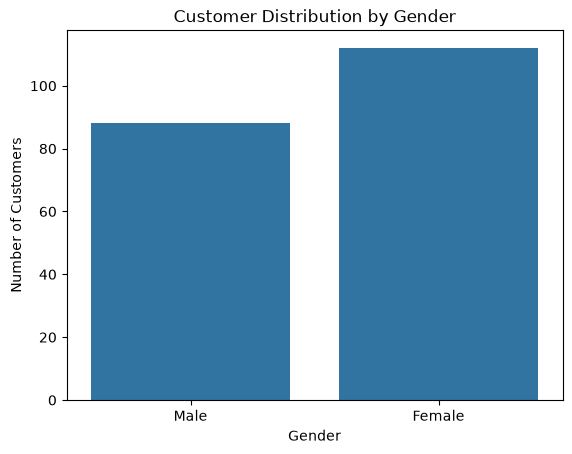

In [7]:
sns.countplot(data=df, x="Genre")

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

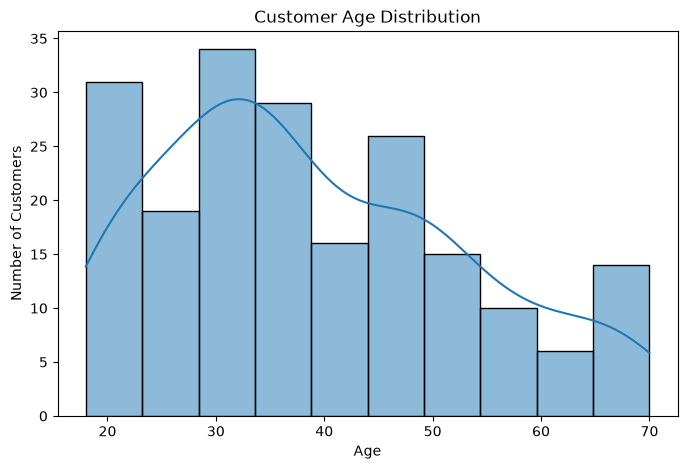

In [8]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Age", bins=10, kde=True)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

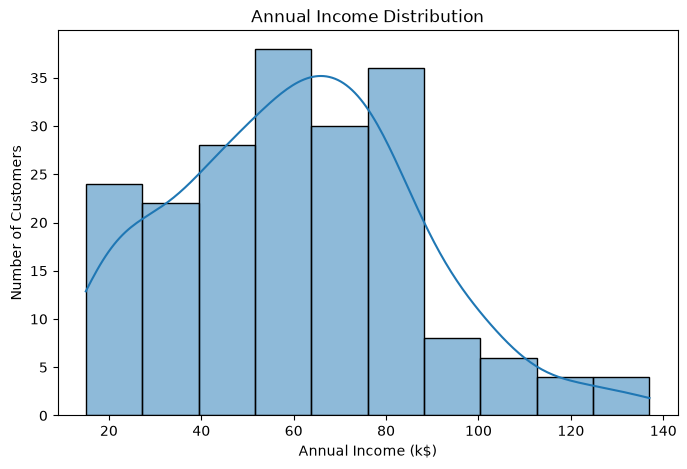

In [9]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Annual Income (k$)", bins=10, kde=True)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of Customers")
plt.show()

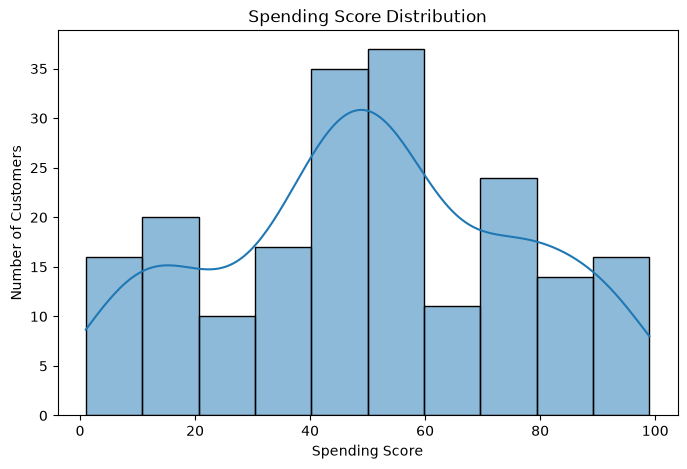

In [10]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Spending Score (1-100)", bins=10, kde=True)

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Number of Customers")
plt.show()

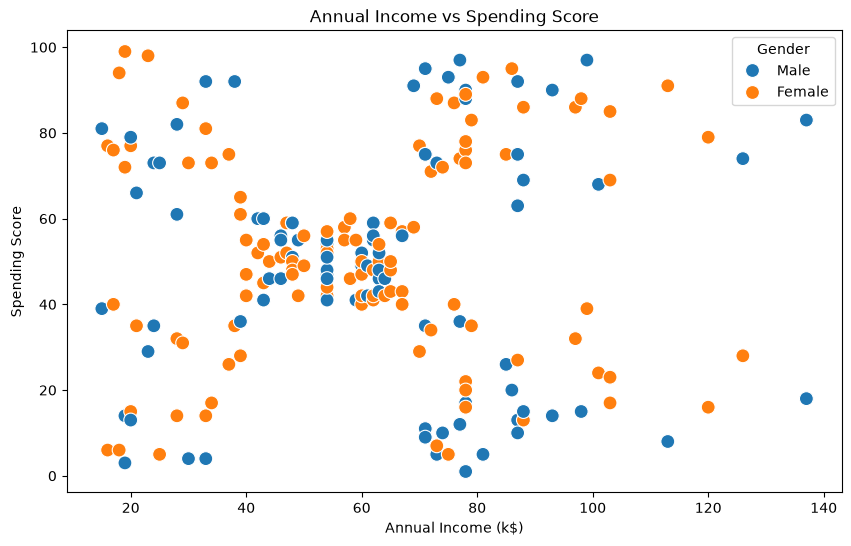

In [11]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Genre",
    s=100
)

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.legend(title="Gender")
plt.show()

In [12]:
from sklearn.cluster import KMeans

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


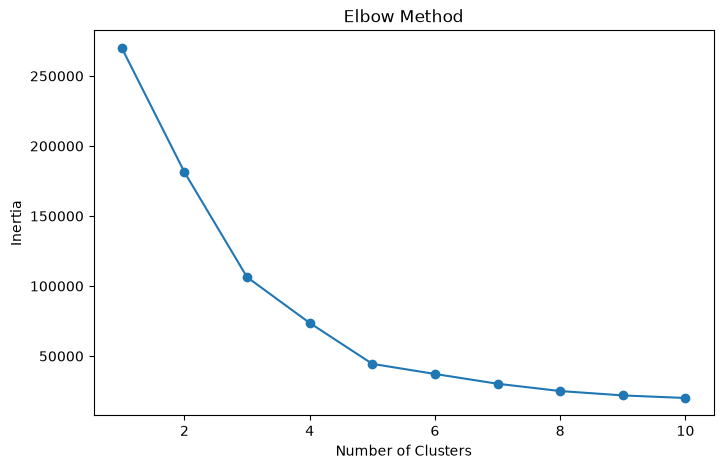

In [13]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [14]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

df['Cluster'] = kmeans.fit_predict(X)

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


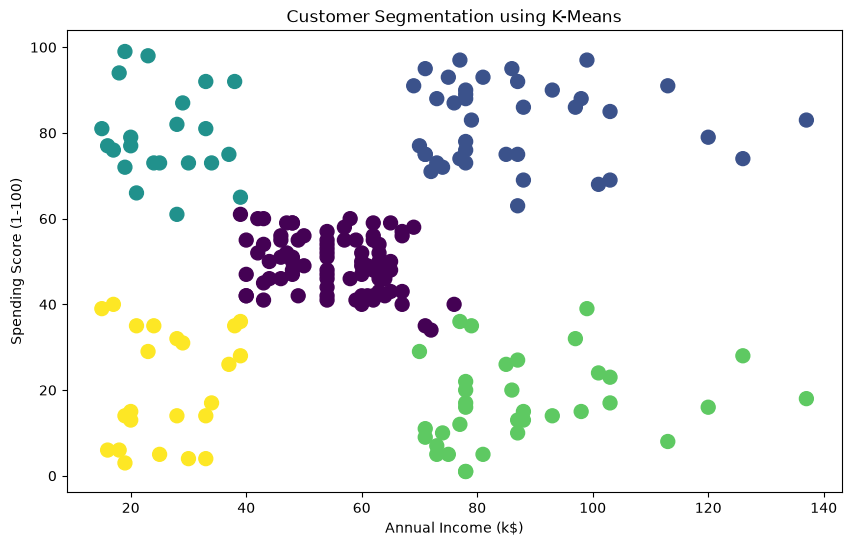

In [15]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    s=100
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segmentation using K-Means')
plt.show()

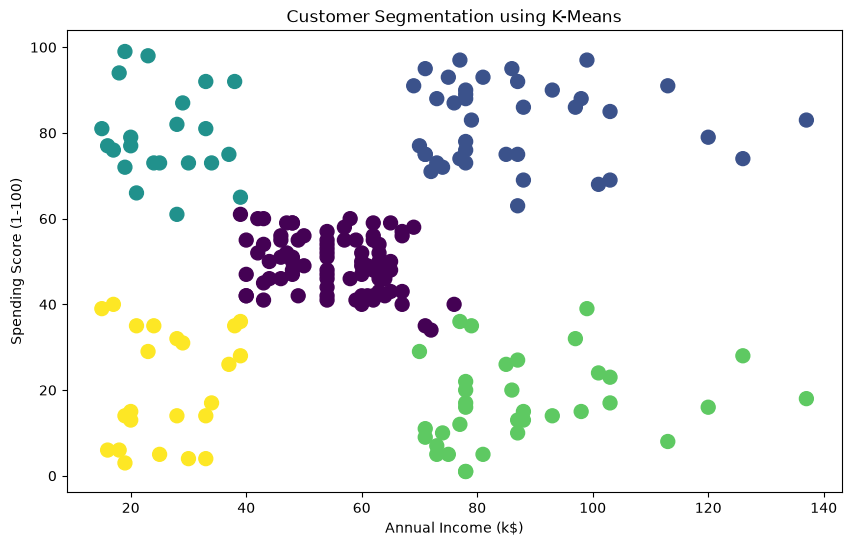

In [16]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    s=100
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segmentation using K-Means')
plt.show()

In [17]:
cluster_summary = df.groupby('Cluster')[
    ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
].mean().round(2)

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.72,55.30,49.52
1,32.69,86.54,82.13
2,25.27,25.73,79.36
3,41.11,88.20,17.11
4,45.22,26.30,20.91


In [18]:
cluster_names = {
    0: 'Average Customers',
    1: 'High-Value Customers',
    2: 'Young High-Spending Customers',
    3: 'High-Income Low-Spending Customers',
    4: 'Low-Income Low-Spending Customers'
}

df['Customer Segment'] = df['Cluster'].map(cluster_names)

df[['CustomerID', 'Genre', 'Age',
   'Annual Income (k$)', 'Spending Score (1-100)',
   'Customer Segment']].head(10)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Customer Segment
0,1,Male,19,15,39,Low-Income Low-Spending Customers
1,2,Male,21,15,81,Young High-Spending Customers
2,3,Female,20,16,6,Low-Income Low-Spending Customers
3,4,Female,23,16,77,Young High-Spending Customers
4,5,Female,31,17,40,Low-Income Low-Spending Customers
5,6,Female,22,17,76,Young High-Spending Customers
6,7,Female,35,18,6,Low-Income Low-Spending Customers
7,8,Female,23,18,94,Young High-Spending Customers
8,9,Male,64,19,3,Low-Income Low-Spending Customers
9,10,Female,30,19,72,Young High-Spending Customers


In [19]:
df['Customer Segment'].value_counts()

Customer Segment
Average Customers                     81
High-Value Customers                  39
High-Income Low-Spending Customers    35
Low-Income Low-Spending Customers     23
Young High-Spending Customers         22
Name: count, dtype: int64

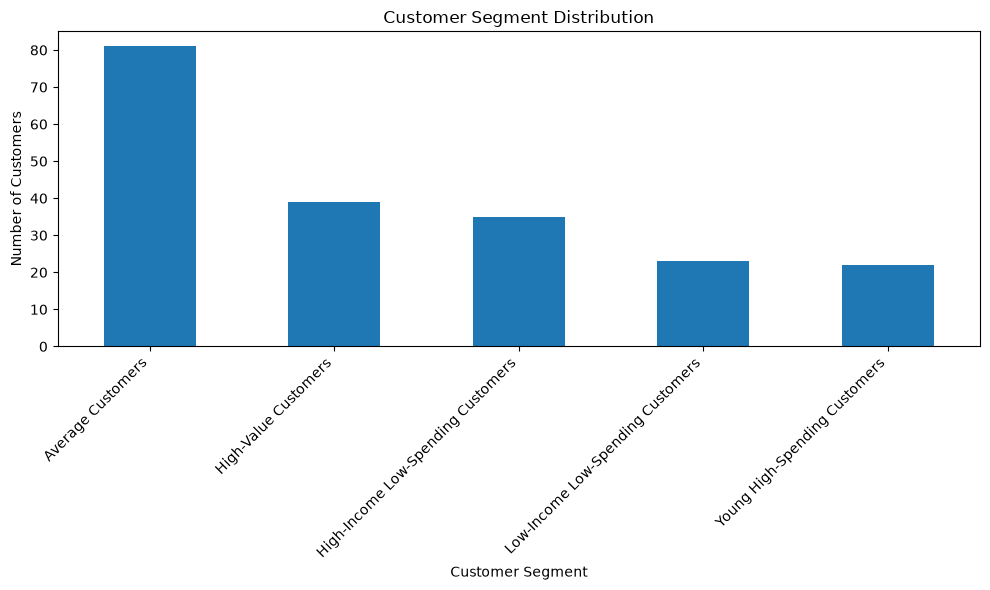

In [20]:
plt.figure(figsize=(10, 6))

df['Customer Segment'].value_counts().plot(kind='bar')

plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.title('Customer Segment Distribution')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

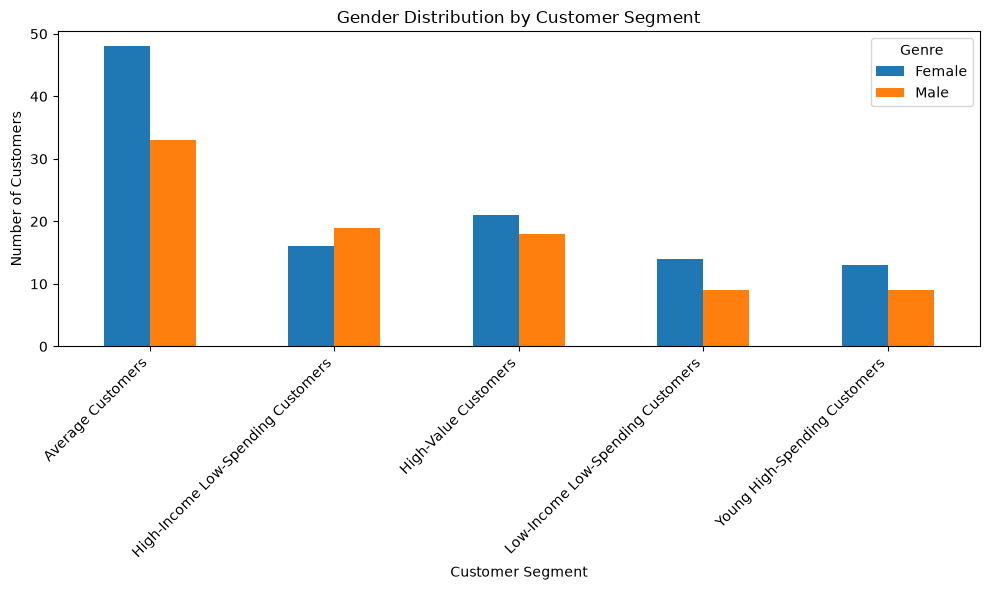

In [21]:
plt.figure(figsize=(10, 6))

pd.crosstab(df['Customer Segment'], df['Genre']).plot(
    kind='bar',
    figsize=(10, 6)
)

plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.title('Gender Distribution by Customer Segment')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [22]:
# Save the final customer segmentation dataset
df.to_csv("customer_segments.csv", index=False)

print("Customer segmentation dataset saved successfully!")

Customer segmentation dataset saved successfully!


In [23]:
import os

print("Files in project folder:")
print(os.listdir())

Files in project folder:
['customer_segmentation.ipynb', 'customer_segments.csv']
